In [197]:
import numpy as np                           # 导入numpy库并简写为np
from mindquantum.core.gates import X, H      # 导入量子门H, X
from mindquantum.simulator import Simulator  # 从mindquantum.simulator中导入Simulator类
from mindquantum.core.circuit import Circuit # 导入Circuit模块，用于搭建量子线路
from mindquantum.core.gates import Measure   # 引入测量门

## State vector

In [198]:
nqubits = 4
postfix = 'sparse_hamiltonian_4_5'

In [199]:
niter = 20
# postfix = 'slater_plus_4to8layers_40iter'
qasm_texts = []
diags = np.zeros((niter, 2**nqubits), dtype=complex)

for i in range(niter):
    with open(f'saved_models/{i}iter_5layers_{postfix}.qasm') as file:
        qasm_texts.append(file.read())
    diags[i] = np.load(f'saved_models/{i}iter_5layers_diag_{postfix}.npy')

In [200]:
def reorder_qubits(x, nqubits):
    return np.transpose(x.reshape([2] * nqubits)).reshape(-1)

In [201]:
from scipy.linalg import eigh

In [202]:
stvec = np.loadtxt('slater/ground_state_dense_hamiltonian_4.txt', dtype=complex, delimiter=",") # this input state is a density matrix

In [203]:
ground_trurh_val = stvec.conjugate().T @ np.load(f"{postfix}.npy") @ stvec
# print(np.trace(np.load("SparseH_8.npy") @ np.load("ground_state_SparseH_8.npy")))
ground_trurh_val

np.complex128(-0.07516323380974917+6.938893903907228e-18j)

In [204]:
import re
import math

def find_eval_replace_expressions(input_string):
    pattern = r'(\d*)/\((\d*)\*pi\)|(\d*)\*pi/(\d*)'
    matches = re.finditer(pattern, input_string)
    updated_string = input_string
    for match in matches:
        num1 = match.group(1) if match.group(1) else match.group(3)
        num2 = match.group(2) if match.group(2) else match.group(4)
        result = eval(f'{num1} / {num2} * math.pi')
        expression = match.group(0)
        updated_string = updated_string.replace(expression, str(result), 1)  # 仅替换第一个匹配项

    return updated_string

In [205]:
#from mindquantum.io import OpenQASM

#circuit = OpenQASM().from_string(find_eval_replace_expressions(qasm_texts[0]))
#circuit.svg()

In [206]:
from mindquantum.io import OpenQASM
estval = 0
sim = Simulator('mqvector', nqubits)

for i in range(niter):
    circuit = OpenQASM().from_string(find_eval_replace_expressions(qasm_texts[i]))
    sim.reset()
    sim.set_qs(reorder_qubits(stvec, nqubits))
    sim.apply_circuit(circuit)
    resstvec = sim.get_qs()
    diags_flip = reorder_qubits(diags[i], nqubits)
    estval += resstvec.conjugate() @ np.diag(diags_flip) @ resstvec

estval_st = estval

estval_st

np.complex128(-0.07516302461183547+5.096021525922788e-18j)

## Sampling

In [207]:
importance = np.max(np.abs(diags), axis=1)

In [208]:
importance /= np.sum(importance)

In [209]:
import matplotlib.pyplot as plt

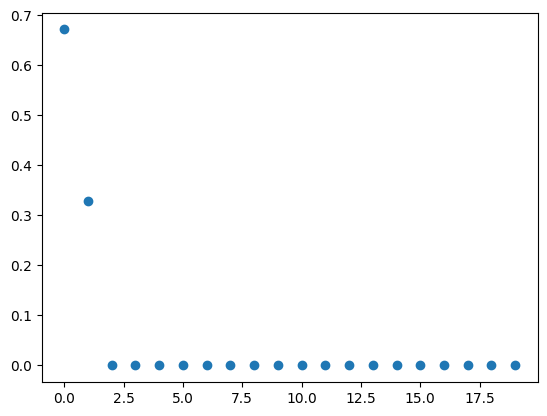

In [210]:
plt.scatter(range(niter), importance)

In [211]:
def estimate_diag(diag_obs, bit_string_data, nshots):
    x = np.array([[n if (j==int(bs, 2)) else 0 for j in range(len(diag_obs))] for bs, n in (bit_string_data.items())])
    x = np.sum(x, axis=0)
    return np.sum(x * diag_obs) / nshots

In [212]:
import math

sim = Simulator('mqvector', nqubits)
nruns = 1

def estimtate(nshots_total):
    estval_list_run = np.zeros(nruns, dtype=complex)
    nshots_iter = [math.floor(nshots_total * x) for x in importance]
    for i in range(niter):
        if nshots_iter[i]:
            circuit = OpenQASM().from_string(find_eval_replace_expressions(qasm_texts[i]))
            for j in range(nqubits):
                circuit += Measure(f'q{j}').on(j)
            diags_flip = reorder_qubits(diags[i], nqubits)
            for j in range(nruns):
                sim.reset()
                sim.set_qs(reorder_qubits(stvec, nqubits))
                result = sim.sampling(circuit, shots=nshots_iter[i])
                contribution = estimate_diag(diags_flip, result.bit_string_data, nshots_iter[i]) 
                estval_list_run[j] += contribution
    return estval_list_run

In [213]:
# nshots_total_list = [12,45,160,572,2038,7256,25848,92041]
# estval_list = np.array([estimtate(n) for n in nshots_total_list]).T
T = [12,45,160,572,2038,7256,25848]
output_file = f'greedy_{postfix}.txt'
with open(output_file, 'w') as f:
    for t in T:
        result = []
        for i in range(50):
            estimated_expectation_value = estimtate(t)
            result.append(estimated_expectation_value)
        print("result:", result)
        # 计算偏差
        cal = ground_trurh_val
        squared_deviations = [np.abs(x - cal) ** 2 for x in result]
        # 计算标准差
        std_dev = np.sqrt(np.mean(squared_deviations))

        np.savetxt(f, [std_dev], fmt='%s', delimiter=" ")

result: [array([-3.98593212e-06+0.j]), array([-1.44967283e-07+0.j]), array([-1.32438641e-06+0.j]), array([-9.38360149e-07+0.j]), array([2.37812882e-06+0.j]), array([-0.17604273+0.j]), array([-0.17604295+0.j]), array([-6.95739808e-07+0.j]), array([-9.90053975e-07+0.j]), array([0.22922831+0.j]), array([-1.58472627e-06+0.j]), array([-1.20335661e-06+0.j]), array([-1.70656713e-06+0.j]), array([5.90340846e-07+0.j]), array([-1.21846973e-06+0.j]), array([-0.22922843+0.j]), array([-1.2880304e-06+0.j]), array([0.22922828+0.j]), array([-0.40527008+0.j]), array([-1.24743981e-06+0.j]), array([0.22923001+0.j]), array([-0.35208448+0.j]), array([-0.22923405+0.j]), array([-4.29940977e-06+0.j]), array([1.14440795e-06+0.j]), array([-1.21353773e-06+0.j]), array([-2.83781606e-06+0.j]), array([-0.22923113+0.j]), array([-0.17604268+0.j]), array([-2.70785199e-06+0.j]), array([-1.9432959e-06+0.j]), array([-0.35208262+0.j]), array([0.22922832+0.j]), array([-0.17604057+0.j]), array([-0.17604281+0.j]), array([-0.

In [ ]:
for j in range(nruns):
    if j==0:
        label = "real"
    else:
        label = None
    plt.scatter(nshots_total_list, estval_list[j], c='blue', s=1, label=label)
plt.plot(nshots_total_list, [estval_st.real] * len(nshots_total_list), "--", label="real - no fluc")
plt.plot(nshots_total_list, [ground_trurh_val.real] * len(nshots_total_list), label="real - ground truth")
plt.legend()

In [ ]:
for j in range(nruns):
    if j==0:
        label = "imag"
    else:
        label = None
    plt.scatter(nshots_total_list, estval_list[j], c='blue', s=1, label=label)
plt.plot(nshots_total_list, [estval_st.real] * len(nshots_total_list), "--", label="imag - no fluc")
plt.plot(nshots_total_list, [ground_trurh_val.real] * len(nshots_total_list), label="imag - ground truth")
plt.legend()

In [ ]:
errors = np.array(estval_list)
errors -= ground_trurh_val
# errors -= estval.real
errors = np.sqrt(np.sum(np.abs(errors)**2, axis=0) / nruns)

In [ ]:
errors

In [ ]:
plt.scatter(nshots_total_list, errors)

In [ ]:
# np.savetxt('plotdata/slater_error.txt', errors)